In [1]:
#below find the latest code


In [ ]:
#below find the latest code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
# ================================
# Define MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero (replace zeros in y_true with a small number)
    return np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-8, y_true))) * 100

# ================================
# Step 1: Load the dataset
print("Loading the dataset...")
df = pd.read_csv("['EGLL']_2023-04-01_00-00-00_till_2024-03-31_00-00-00_stack_cleaned_RECAT.csv")

# Optionally drop a redundant index column if present.
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df['Time Sine'] = np.sin(2 * np.pi * df['Decimal Hours'] / 24)
df['Time Cosine'] = np.cos(2 * np.pi * df['Decimal Hours'] / 24)

df=df.drop(columns=['WTC L', 'WTC M', 'WTC H','WTC J','Decimal Hours','day','month','year','day_of_week','wind dir','wind speed'])

# Renaming columns
df = df.rename(columns={
    'Holding Time Big': 'Holding Time at BIG',
    'Holding Time Ock': 'Holding Time at OCK',
    'Holding Time Bov': 'Holding Time at BNN',
    'Holding Time Lam': 'Holding Time at LAM',
    'TimeStamp': 'TimeStamp',
    'Big': 'Number of Aircraft at BIG',
    'Ock': 'Number of Aircraft at OCK',
    'Bov': 'Number of Aircraft at BNN',
    'Lam': 'Number of Aircraft at LAM',
    'day_of_week': 'Day of the week',
    'Big Max': 'Maximum Holding Time at BIG',
    'Big Min': 'Minimum holding Time at BIG',
    'Ock Max': 'Maximum Holding Time at OCK',
    'Ock Min': 'Minimum holding Time at OCK',
    'Bov Max': 'Maximum Holding Time at BNN',
    'Bov Min': 'Minimum holding Time at BNN',
    'Lam Max': 'Maximum Holding Time at LAM',
    'Lam Min': 'Minimum holding Time at LAM',
    'Runway 09L': 'Total Landed at Runway 09L',
    'Runway 09R': 'Total Landed at Runway 09R',
    'Runway 27L': 'Total Landed at Runway 27L',
    'Runway 27R': 'Total Landed at Runway 27R',
    'No of Landings 1HR': 'Total Landings Last Hour',
    'No stack': 'Aircrafts Not Using any Stack',
    'ceiling': 'Ceiling Score',
    'wind': 'Wind Score',
    'precip': 'Precip Score',
    'freezing': 'Freezing Score',
    'phenomena': 'Phenomena Score',
    'wind dir': 'Wind Direction',
    'wind speed': 'Wind Speed',
    'Crosswind Component': 'Crosswind Component',
    'Headwind Component': 'Headwind Component',
    'departures_delayIndex': 'Departures Delay Index',
    'arrivals_numCancelled': 'Total Arrivals Cancelled Flights',
    'arrivals_delayIndex': 'Arrivals Delay Index',
    'RECAT_EU_A': 'Number of RECAT EU A', 
    'RECAT_EU_B': 'Number of RECAT EU B', 
    'RECAT_EU_C': 'Number of RECAT EU C', 
    'RECAT_EU_D': 'Number of RECAT EU D', 
    'RECAT_EU_E': 'Number of RECAT EU E',
    'RECAT_EU_F': 'Number of RECAT EU F',
    'Engine_Jet': 'Number of Jet Engines', 
    'Engine_Turboprop_shaft': 'Number of Turboprop Engines',
    'Day_0':'Monday',
    'Day_1':'Tuesday', 
    'Day_2': 'Wednesday', 
    'Day_3':'Thursday', 
    'Day_4': 'Friday', 
    'Day_5': 'Saturday',
     'Day_6' :'Sunday'
    
})



print("Converting timestamps and setting index...")
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
df.set_index('TimeStamp', inplace=True)

df.columns

In [ ]:
# ================================
# Step 2: Define features and target.
features = list(df.columns)  
target = "Holding Time at BIG"  # Forecast this column

# ================================
# Step 3: Prepare the data.
X = df[features].values # ALL STACK FEATURES
y = df[target].values.reshape(-1, 1) # TARGET STACK ONLY

# ================================
# Step 4: Scale the data (inputs and target separately)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# ================================
# Step 5: Train-test split BEFORE scaling
split_index = int(len(df) * 0.80)
X_train_raw, X_test_raw = X[:split_index], X[split_index:]
y_train_raw, y_test_raw = y[:split_index], y[split_index:]

# Fit scalers on TRAIN ONLY (avoid leakage)
X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)


# ================================
# Step 5: Create time-window sequences.
def createXY(X, y, n_past):
    dataX, dataY = [], []
    for i in range(n_past, len(X)):
        dataX.append(X[i - n_past:i, :])
        dataY.append(y[i, 0])
    return np.array(dataX), np.array(dataY)

n_past = 30  # length of the time window

trainX, trainY = createXY(X_train_scaled, y_train_scaled, n_past)
testX, testY   = createXY(X_test_scaled, y_test_scaled, n_past)

print("trainX shape:", trainX.shape)
print("trainY shape:", trainY.shape)
print("testX shape:", testX.shape)
print("testY shape:", testY.shape)

# ================================
# Step 6: Define the LSTM model creation function.
# Now we include learning_rate and dropout as arguments.
def build_model(input_shape, optimizer='adam', learning_rate=0.001, dropout=0.2):
    # Create an optimizer instance with the chosen learning rate
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'adadelta':
        opt = tf.keras.optimizers.Adadelta(learning_rate=learning_rate)
    else:
        # Fallback
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(50, return_sequences=True))
    model.add(LSTM(50))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=opt)
    return model

# ================================
# (Optional) Step 7: Define a forecasting function.
def forecast(model, X_dataset, n_past, n_future):
    # Use the last window from X_dataset as the starting point.
    forecast_input = X_dataset[-n_past:]  # shape: (n_past, num_features)
    forecast_output = []
    for _ in range(n_future):
        forecast_input_reshaped = forecast_input.reshape(1, n_past, forecast_input.shape[1])
        prediction = model.predict(forecast_input_reshaped)
        forecast_output.append(prediction[0, 0])
        # For forecasting, update only the target feature (assumed to be the first column).
        new_input = forecast_input[-1].copy()
        new_input[0] = prediction
        forecast_input = np.vstack([forecast_input[1:], new_input])
    return np.array(forecast_output)

# ================================
# Step 8: Hyperparameter tuning using GridSearchCV with scikeras.
input_shape = (trainX.shape[1], trainX.shape[2])

grid_model = KerasRegressor(
    model=build_model,
    input_shape=input_shape,
    # Default top-level parameters
    optimizer="adam",
    epochs=10,
    batch_size=32,
    verbose=1,
    # Default custom model parameters
    model__dropout=0.2,
    model__learning_rate=0.01
)

parameters = {
    'batch_size': [16, 32],              
    'epochs': [8, 10],                   
    'optimizer': ['adam', 'adadelta'],   
    'model__learning_rate': [0.01, 0.05, 0.1],  
    'model__dropout': [0.2, 0.4,0.6],           
}

grid_search = GridSearchCV(estimator=grid_model, param_grid=parameters, cv=2)
print("Starting GridSearchCV...")
grid_search.fit(trainX, trainY)


In [ ]:
print("Grid Search Parameter grid:", grid_search.param_grid)
print("Best parameters:", grid_search.best_params_)

# Extract best Keras model
best_model = grid_search.best_estimator_.model_

# ================================
# Step 9: Evaluate the model on the test set.
pred_scaled = best_model.predict(testX)
pred_rescaled = scaler_y.inverse_transform(pred_scaled)
true_rescaled = scaler_y.inverse_transform(testY.reshape(-1, 1))

mae = mean_absolute_error(true_rescaled, pred_rescaled)
mse = mean_squared_error(true_rescaled, pred_rescaled)
mape = mean_absolute_percentage_error(true_rescaled, pred_rescaled)

print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test MAPE:", mape, "%")

In [ ]:
# ================================
# Step 10: SHAP Analysis and Beeswarm Plot for All Features.
import shap

try:
    @tf.RegisterGradient("shap_AddV2")
    def _shap_add_v2_grad(op, grad):
        return [grad, tf.zeros_like(grad)]
except KeyError:
    print("shap_AddV2 gradient already registered. Skipping re-registration.")

X_train_flat = trainX.reshape(trainX.shape[0], -1)
X_test_flat  = testX.reshape(testX.shape[0], -1)
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

def predict_function(flat_data):
    batch_size = flat_data.shape[0]
    reshaped = flat_data.reshape((batch_size, n_past, trainX.shape[2]))
    return best_model.predict(reshaped).flatten()

np.random.seed(42)
idx = np.random.choice(X_train_flat.shape[0], size=50, replace=False)
background_data = X_train_flat[idx]

explainer = shap.KernelExplainer(model=predict_function, data=background_data, link="identity")

test_subset = X_test_flat[:50]
print("Calculating SHAP values on test subset...")
shap_values = explainer.shap_values(test_subset)
print("SHAP values shape (flattened):", np.array(shap_values).shape)

num_samples = test_subset.shape[0]
n_features = trainX.shape[2]
shap_values_reshaped = np.array(shap_values).reshape(num_samples, n_past, n_features)

aggregated_shap = np.mean(shap_values_reshaped, axis=1)  # (num_samples, n_features)

test_subset_unflat = testX[:50]
aggregated_X_test = np.mean(test_subset_unflat, axis=1)  # (num_samples, n_features)

shap.summary_plot(aggregated_shap, aggregated_X_test, feature_names=features,max_display=10, show=False)
plt.tight_layout()
plt.savefig(f'plots\LSTM\{target}\Aggregated_Beeswarm_All_Features.png')
plt.close()
print("Aggregated beeswarm plot saved as 'Aggregated_Beeswarm_All_Features.png'.")

# ================================
# Step 11: (Optional) Forecast future target values.
n_future = 50
forecasted_scaled = forecast(best_model, X_train_scaled, n_past, n_future)
forecasted = scaler_y.inverse_transform(forecasted_scaled.reshape(-1, 1)).flatten()

# ================================
# Step 12: Generate future dates for forecasting.
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=n_future+1, freq='15T')[1:]

# ================================
# Step 13: Plot the test predictions and forecast.
adjusted_test_index = df.index[split_index + n_past:]
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_rescaled, label='Original')
plt.plot(adjusted_test_index, predictions_rescaled, label='Predicted')
#plt.plot(future_dates, forecasted, label='Forecasted', linestyle='dashed', color='green')
#plt.title("Prediction and Forecasting")
plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
plt.show()

# ================================
# Step 14: Save the results to CSV.
results_df = pd.DataFrame({
    'Date': adjusted_test_index.tolist() + future_dates.tolist(),
    'Original': np.concatenate([original_rescaled, [np.nan]*len(future_dates)]),
    'Predicted': np.concatenate([predictions_rescaled, [np.nan]*len(future_dates)]),
    'Forecasted': np.concatenate([[np.nan]*len(original_rescaled), forecasted])
})
results_df.to_csv("Multivariate_Results_BIG.csv", index=False)
print("Results saved to 'Multivariate_Results_BIG.csv'.")

In [ ]:
# Flatten arrays to 1D
original_rescaled_flat = original_rescaled.ravel()
predictions_rescaled_flat = predictions_rescaled.ravel()

# Convert to pandas Series with date index
original_series = pd.Series(original_rescaled_flat, index=adjusted_test_index)
predicted_series = pd.Series(predictions_rescaled_flat, index=adjusted_test_index)

# Apply rolling average 
window = 24  #(4=1hour 24=6hours)
original_smoothed = original_series.rolling(window).mean()
predicted_smoothed = predicted_series.rolling(window).mean()

# Plot smoothed data
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_smoothed, label='Original', linewidth=2)
plt.plot(adjusted_test_index, predicted_smoothed, label='Predicted', linewidth=2)

plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
#plt.grid(True)
#plt.tight_layout()
plt.show()


In [10]:
# ================================
# Step 2: Define features and target.
features = list(df.columns)  
target = "Holding Time at LAM"  # Forecast this column

# ================================
# Step 3: Prepare the data.
X = df[features].values
y = df[target].values.reshape(-1, 1)

# ================================
# Step 4: Scale the data (inputs and target separately)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# ================================
# Step 5: Create time-window sequences.
def createXY(X, y, n_past):
    dataX, dataY = [], []
    for i in range(n_past, len(X)):
        dataX.append(X[i - n_past:i, :])
        dataY.append(y[i, 0])
    return np.array(dataX), np.array(dataY)

n_past = 30  # length of the time window

split_index = int(len(df) * 0.80)
X_train_scaled, X_test_scaled = X_scaled[:split_index], X_scaled[split_index:]
y_train_scaled, y_test_scaled = y_scaled[:split_index], y_scaled[split_index:]

trainX, trainY = createXY(X_train_scaled, y_train_scaled, n_past)
testX, testY   = createXY(X_test_scaled, y_test_scaled, n_past)
print("trainX shape:", trainX.shape, "trainY shape:", trainY.shape)
print("testX shape:", testX.shape, "testY shape:", testY.shape)

# ================================
# Step 6: Define the LSTM model creation function.
# Now we include learning_rate and dropout as arguments.
def build_model(input_shape, optimizer='adam', learning_rate=0.001, dropout=0.2):
    # Create an optimizer instance with the chosen learning rate
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'adadelta':
        opt = tf.keras.optimizers.Adadelta(learning_rate=learning_rate)
    else:
        # Fallback
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(50, return_sequences=True))
    model.add(LSTM(50))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=opt)
    return model

# ================================
# (Optional) Step 7: Define a forecasting function.
def forecast(model, X_dataset, n_past, n_future):
    # Use the last window from X_dataset as the starting point.
    forecast_input = X_dataset[-n_past:]  # shape: (n_past, num_features)
    forecast_output = []
    for _ in range(n_future):
        forecast_input_reshaped = forecast_input.reshape(1, n_past, forecast_input.shape[1])
        prediction = model.predict(forecast_input_reshaped)
        forecast_output.append(prediction[0, 0])
        # For forecasting, update only the target feature (assumed to be the first column).
        new_input = forecast_input[-1].copy()
        new_input[0] = prediction
        forecast_input = np.vstack([forecast_input[1:], new_input])
    return np.array(forecast_output)

# ================================
# Step 8: Hyperparameter tuning using GridSearchCV with scikeras.
input_shape = (trainX.shape[1], trainX.shape[2])

grid_model = KerasRegressor(
    model=build_model,
    input_shape=input_shape,
    # Default top-level parameters
    optimizer="adam",
    epochs=10,
    batch_size=32,
    verbose=1,
    # Default custom model parameters
    model__dropout=0.2,
    model__learning_rate=0.01
)

parameters = {
    'batch_size': [16, 32],              
    'epochs': [8, 10],                   
    'optimizer': ['adam', 'adadelta'],   
    'model__learning_rate': [0.01, 0.05, 0.1],  
    'model__dropout': [0.2, 0.4,0.6],           
}

grid_search = GridSearchCV(estimator=grid_model, param_grid=parameters, cv=2)
print("Starting GridSearchCV...")
grid_search.fit(trainX, trainY)


trainX shape: (27848, 30, 49) trainY shape: (27848,)
testX shape: (6940, 30, 49) testY shape: (6940,)
Starting GridSearchCV...
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0064
Epoch 2/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0035
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0035
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0035
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0035
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0033
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0035
Epoch 8/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0037
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0035
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0037
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0035
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0032
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - lo

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0023
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0024
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0025
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0023
Epoch 8/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0023
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 0.0413
Epoch 2/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0039
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0040
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0042
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0039
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0041
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0046
Epoch 8/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0044
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 19s 1

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0031
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0032
Epoch 9/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0031
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0029
Epoch 5/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0026
Epoch 6/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0027
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0026
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0023
Epoch 9/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.0023
Epoch 10/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0024
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
Epoch 1/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.0099
Epoch 2/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0037
Epoch 3/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0036
Epoch 4/10
535/871 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0036 

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0182
Epoch 8/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0248
436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0114
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0038
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0035
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0032
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0036
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0033
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0032
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0033
Epoch 9/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0032
Epoch 10/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0031
436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0079
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



436/436 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0038
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0035
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0035
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0026
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0027
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0025
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0025
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0024
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0025
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0025
Epoch 9/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0022
Epoch 10/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0022
436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.0943
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0043
Epoch 

GridSearchCV(cv=2,
             estimator=KerasRegressor(batch_size=32, epochs=10, input_shape=(30, 49), model=<function build_model at 0x000001B4EDFD6C20>, model__dropout=0.2, model__learning_rate=0.01, optimizer='adam'),
             param_grid={'batch_size': [16, 32], 'epochs': [8, 10],
                         'model__dropout': [0.2, 0.4, 0.6],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'optimizer': ['adam', 'adadelta']})

In [11]:
print("Grid Search Parameter grid:", grid_search.param_grid)
print("Best parameters:", grid_search.best_params_)

# Extract best Keras model
best_model = grid_search.best_estimator_.model_

# ================================
# Step 9: Evaluate the model on the test set.
predictions = best_model.predict(testX)
predictions_rescaled = scaler_y.inverse_transform(predictions)
original_rescaled = scaler_y.inverse_transform(testY.reshape(-1, 1))
mae = mean_absolute_error(original_rescaled, predictions_rescaled)
mse = mean_squared_error(original_rescaled, predictions_rescaled)
mape = mean_absolute_percentage_error(original_rescaled, predictions_rescaled)
print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test MAPE:", mape, "%")

Grid Search Parameter grid: {'batch_size': [16, 32], 'epochs': [8, 10], 'optimizer': ['adam', 'adadelta'], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__dropout': [0.2, 0.4, 0.6]}
Best parameters: {'batch_size': 32, 'epochs': 8, 'model__dropout': 0.4, 'model__learning_rate': 0.01, 'optimizer': 'adam'}
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Test MAE: 1.2042179395876804
Test MSE: 4.699844629439245
Test MAPE: 3368560615.2885413 %


shap_AddV2 gradient already registered. Skipping re-registration.
X_train_flat shape: (27848, 1470)
X_test_flat shape: (6940, 1470)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Calculating SHAP values on test subset...


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
7519/7519 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/steps/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7128/7519 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
7522/7522 ━━━━━━━━━━━━━━━━━━━━ 54s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 54s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step
1/1 ━━━━━━━━━━━━

C:\Users\mic__\AppData\Local\Temp\ipykernel_14212\1754747065.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_input[0] = prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

C:\Users\mic__\AppData\Local\Temp\ipykernel_14212\1888913242.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_dates = pd.date_range(last_date, periods=n_future+1, freq='15T')[1:]


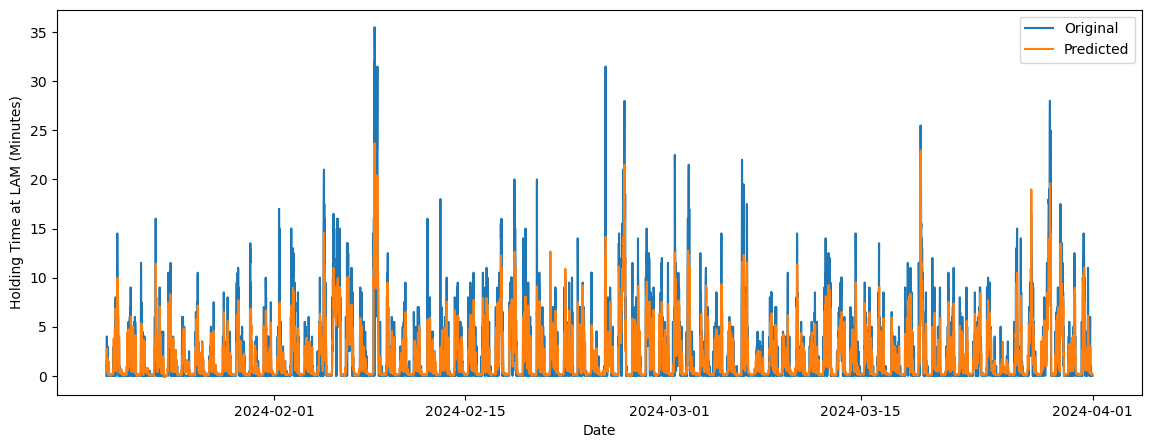

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [12]:
# ================================
# Step 10: SHAP Analysis and Beeswarm Plot for All Features.
import shap

try:
    @tf.RegisterGradient("shap_AddV2")
    def _shap_add_v2_grad(op, grad):
        return [grad, tf.zeros_like(grad)]
except KeyError:
    print("shap_AddV2 gradient already registered. Skipping re-registration.")

X_train_flat = trainX.reshape(trainX.shape[0], -1)
X_test_flat  = testX.reshape(testX.shape[0], -1)
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

def predict_function(flat_data):
    batch_size = flat_data.shape[0]
    reshaped = flat_data.reshape((batch_size, n_past, trainX.shape[2]))
    return best_model.predict(reshaped).flatten()

np.random.seed(42)
idx = np.random.choice(X_train_flat.shape[0], size=50, replace=False)
background_data = X_train_flat[idx]

explainer = shap.KernelExplainer(model=predict_function, data=background_data, link="identity")

test_subset = X_test_flat[:100]
print("Calculating SHAP values on test subset...")
shap_values = explainer.shap_values(test_subset)
print("SHAP values shape (flattened):", np.array(shap_values).shape)

num_samples = test_subset.shape[0]
n_features = trainX.shape[2]
shap_values_reshaped = np.array(shap_values).reshape(num_samples, n_past, n_features)

aggregated_shap = np.mean(shap_values_reshaped, axis=1)  # (num_samples, n_features)

test_subset_unflat = testX[:100]
aggregated_X_test = np.mean(test_subset_unflat, axis=1)  # (num_samples, n_features)

shap.summary_plot(aggregated_shap, aggregated_X_test, feature_names=features,max_display=10, show=False)
plt.tight_layout()
plt.savefig(f'plots\LSTM\{target}\Aggregated_Beeswarm_All_Features.png')
plt.close()
print("Aggregated beeswarm plot saved as 'Aggregated_Beeswarm_All_Features.png'.")

# ================================
# Step 11: (Optional) Forecast future target values.
n_future = 50
forecasted_scaled = forecast(best_model, X_train_scaled, n_past, n_future)
forecasted = scaler_y.inverse_transform(forecasted_scaled.reshape(-1, 1)).flatten()

# ================================
# Step 12: Generate future dates for forecasting.
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=n_future+1, freq='15T')[1:]

# ================================
# Step 13: Plot the test predictions and forecast.
adjusted_test_index = df.index[split_index + n_past:]
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_rescaled, label='Original')
plt.plot(adjusted_test_index, predictions_rescaled, label='Predicted')
#plt.plot(future_dates, forecasted, label='Forecasted', linestyle='dashed', color='green')
#plt.title("Prediction and Forecasting")
plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
plt.show()

# ================================
# Step 14: Save the results to CSV.
results_df = pd.DataFrame({
    'Date': adjusted_test_index.tolist() + future_dates.tolist(),
    'Original': np.concatenate([original_rescaled, [np.nan]*len(future_dates)]),
    'Predicted': np.concatenate([predictions_rescaled, [np.nan]*len(future_dates)]),
    'Forecasted': np.concatenate([[np.nan]*len(original_rescaled), forecasted])
})
results_df.to_csv("Multivariate_Results_LAM.csv", index=False)
print("Results saved to 'Multivariate_Results_LAM.csv'.")

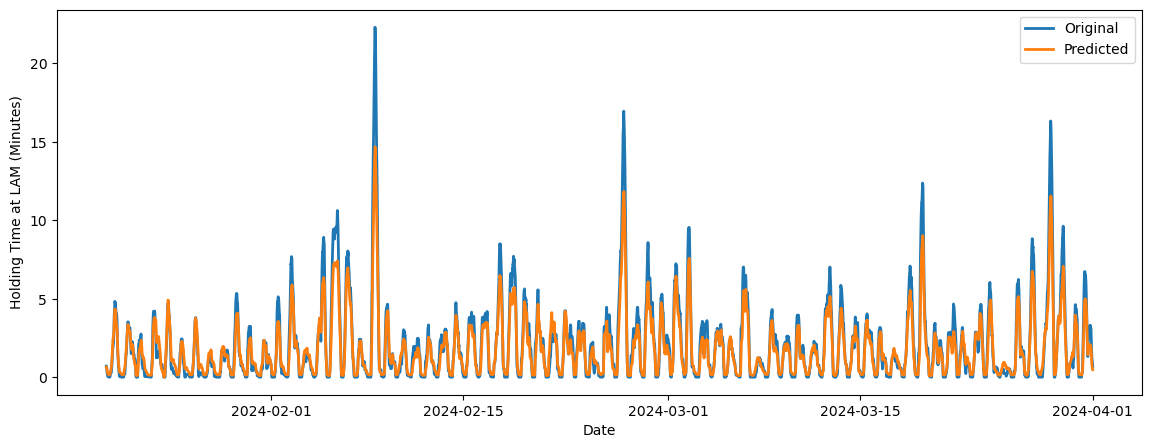

In [14]:
# Flatten arrays to 1D
original_rescaled_flat = original_rescaled.ravel()
predictions_rescaled_flat = predictions_rescaled.ravel()

# Convert to pandas Series with date index
original_series = pd.Series(original_rescaled_flat, index=adjusted_test_index)
predicted_series = pd.Series(predictions_rescaled_flat, index=adjusted_test_index)

# Apply rolling average 
window = 24  #(4=1hour 24=6hours)
original_smoothed = original_series.rolling(window).mean()
predicted_smoothed = predicted_series.rolling(window).mean()

# Plot smoothed data
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_smoothed, label='Original', linewidth=2)
plt.plot(adjusted_test_index, predicted_smoothed, label='Predicted', linewidth=2)

plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
#plt.grid(True)
#plt.tight_layout()
plt.show()


In [15]:
# ================================
# Step 2: Define features and target.
features = list(df.columns)  
target = "Holding Time at OCK"  # Forecast this column

# ================================
# Step 3: Prepare the data.
X = df[features].values
y = df[target].values.reshape(-1, 1)

# ================================
# Step 4: Scale the data (inputs and target separately)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# ================================
# Step 5: Create time-window sequences.
def createXY(X, y, n_past):
    dataX, dataY = [], []
    for i in range(n_past, len(X)):
        dataX.append(X[i - n_past:i, :])
        dataY.append(y[i, 0])
    return np.array(dataX), np.array(dataY)

n_past = 30  # length of the time window

split_index = int(len(df) * 0.80)
X_train_scaled, X_test_scaled = X_scaled[:split_index], X_scaled[split_index:]
y_train_scaled, y_test_scaled = y_scaled[:split_index], y_scaled[split_index:]

trainX, trainY = createXY(X_train_scaled, y_train_scaled, n_past)
testX, testY   = createXY(X_test_scaled, y_test_scaled, n_past)
print("trainX shape:", trainX.shape, "trainY shape:", trainY.shape)
print("testX shape:", testX.shape, "testY shape:", testY.shape)

# ================================
# Step 6: Define the LSTM model creation function.
# Now we include learning_rate and dropout as arguments.
def build_model(input_shape, optimizer='adam', learning_rate=0.001, dropout=0.2):
    # Create an optimizer instance with the chosen learning rate
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'adadelta':
        opt = tf.keras.optimizers.Adadelta(learning_rate=learning_rate)
    else:
        # Fallback
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(50, return_sequences=True))
    model.add(LSTM(50))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=opt)
    return model

# ================================
# (Optional) Step 7: Define a forecasting function.
def forecast(model, X_dataset, n_past, n_future):
    # Use the last window from X_dataset as the starting point.
    forecast_input = X_dataset[-n_past:]  # shape: (n_past, num_features)
    forecast_output = []
    for _ in range(n_future):
        forecast_input_reshaped = forecast_input.reshape(1, n_past, forecast_input.shape[1])
        prediction = model.predict(forecast_input_reshaped)
        forecast_output.append(prediction[0, 0])
        # For forecasting, update only the target feature (assumed to be the first column).
        new_input = forecast_input[-1].copy()
        new_input[0] = prediction
        forecast_input = np.vstack([forecast_input[1:], new_input])
    return np.array(forecast_output)

# ================================
# Step 8: Hyperparameter tuning using GridSearchCV with scikeras.
input_shape = (trainX.shape[1], trainX.shape[2])

grid_model = KerasRegressor(
    model=build_model,
    input_shape=input_shape,
    # Default top-level parameters
    optimizer="adam",
    epochs=10,
    batch_size=32,
    verbose=1,
    # Default custom model parameters
    model__dropout=0.2,
    model__learning_rate=0.01
)

parameters = {
    'batch_size': [16, 32],              # top-level param
    'epochs': [8, 10],                   # top-level param
    'optimizer': ['adam', 'adadelta'],   # top-level param
    'model__learning_rate': [0.01, 0.05, 0.1],  # custom model param
    'model__dropout': [0.2, 0.4,0.6],           # custom model param
}

grid_search = GridSearchCV(estimator=grid_model, param_grid=parameters, cv=2)
print("Starting GridSearchCV...")
grid_search.fit(trainX, trainY)


trainX shape: (27848, 30, 49) trainY shape: (27848,)
testX shape: (6940, 30, 49) testY shape: (6940,)
Starting GridSearchCV...
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0082
Epoch 2/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0041
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0042
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0043
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0041
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0042
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0037
Epoch 8/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0038
871/871 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0084
Epoch 2/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0028
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0028
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - loss: 0.0027
Epoch 5/8
871/87

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



871/871 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 0.0093
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0087
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Epoch 1/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - loss: 0.0625
Epoch 2/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0068
Epoch 3/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0052
Epoch 4/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0048
Epoch 5/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0056
Epoch 6/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0054
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0054
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0053
Epoch 9/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0053
Epoch 10/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0054
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Epoch 1/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0103
Epoch 2/8
436/436 ━━━━━━━━━━━━━━

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [16]:
print("Grid Search Parameter grid:", grid_search.param_grid)
print("Best parameters:", grid_search.best_params_)

# Extract best Keras model
best_model = grid_search.best_estimator_.model_

# ================================
# Step 9: Evaluate the model on the test set.
predictions = best_model.predict(testX)
predictions_rescaled = scaler_y.inverse_transform(predictions)
original_rescaled = scaler_y.inverse_transform(testY.reshape(-1, 1))
mae = mean_absolute_error(original_rescaled, predictions_rescaled)
mse = mean_squared_error(original_rescaled, predictions_rescaled)
mape = mean_absolute_percentage_error(original_rescaled, predictions_rescaled)
print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test MAPE:", mape, "%")

Grid Search Parameter grid: {'batch_size': [16, 32], 'epochs': [8, 10], 'optimizer': ['adam', 'adadelta'], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__dropout': [0.2, 0.4, 0.6]}
Best parameters: {'batch_size': 32, 'epochs': 8, 'model__dropout': 0.6, 'model__learning_rate': 0.01, 'optimizer': 'adam'}
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Test MAE: 1.4842668421920764
Test MSE: 6.011177999885119
Test MAPE: 6552449791.651052 %


shap_AddV2 gradient already registered. Skipping re-registration.
X_train_flat shape: (27848, 1470)
X_test_flat shape: (6940, 1470)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Calculating SHAP values on test subset...


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
7525/7525 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
7519/7519 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
7525/7525 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
7519/7519 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
7519/7519 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
7519/7519 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step
1/1

C:\Users\mic__\AppData\Local\Temp\ipykernel_14212\3760997000.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_input[0] = prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━

C:\Users\mic__\AppData\Local\Temp\ipykernel_14212\2939340930.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_dates = pd.date_range(last_date, periods=n_future+1, freq='15T')[1:]


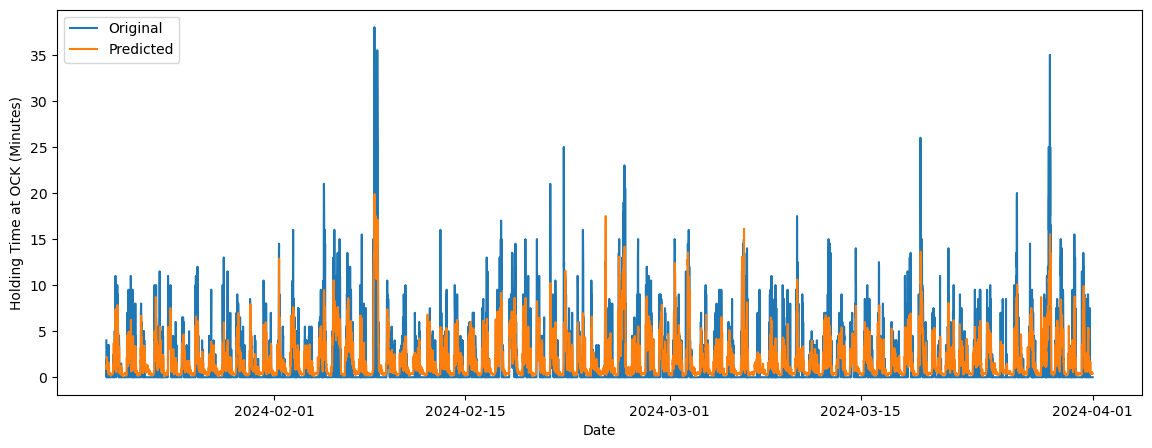

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [17]:
# ================================
# Step 10: SHAP Analysis and Beeswarm Plot for All Features.
import shap

try:
    @tf.RegisterGradient("shap_AddV2")
    def _shap_add_v2_grad(op, grad):
        return [grad, tf.zeros_like(grad)]
except KeyError:
    print("shap_AddV2 gradient already registered. Skipping re-registration.")

X_train_flat = trainX.reshape(trainX.shape[0], -1)
X_test_flat  = testX.reshape(testX.shape[0], -1)
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

def predict_function(flat_data):
    batch_size = flat_data.shape[0]
    reshaped = flat_data.reshape((batch_size, n_past, trainX.shape[2]))
    return best_model.predict(reshaped).flatten()

np.random.seed(42)
idx = np.random.choice(X_train_flat.shape[0], size=50, replace=False)
background_data = X_train_flat[idx]

explainer = shap.KernelExplainer(model=predict_function, data=background_data, link="identity")

test_subset = X_test_flat[:100]
print("Calculating SHAP values on test subset...")
shap_values = explainer.shap_values(test_subset)
print("SHAP values shape (flattened):", np.array(shap_values).shape)

num_samples = test_subset.shape[0]
n_features = trainX.shape[2]
shap_values_reshaped = np.array(shap_values).reshape(num_samples, n_past, n_features)

aggregated_shap = np.mean(shap_values_reshaped, axis=1)  # (num_samples, n_features)

test_subset_unflat = testX[:100]
aggregated_X_test = np.mean(test_subset_unflat, axis=1)  # (num_samples, n_features)

shap.summary_plot(aggregated_shap, aggregated_X_test, feature_names=features, max_display=10, show=False)
plt.tight_layout()
plt.savefig(f'plots\LSTM\{target}\Aggregated_Beeswarm_All_Features.png')
plt.close()
print("Aggregated beeswarm plot saved as 'Aggregated_Beeswarm_All_Features.png'.")

# ================================
# Step 11: (Optional) Forecast future target values.
n_future = 50
forecasted_scaled = forecast(best_model, X_train_scaled, n_past, n_future)
forecasted = scaler_y.inverse_transform(forecasted_scaled.reshape(-1, 1)).flatten()

# ================================
# Step 12: Generate future dates for forecasting.
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=n_future+1, freq='15T')[1:]

# ================================
# Step 13: Plot the test predictions and forecast.
adjusted_test_index = df.index[split_index + n_past:]
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_rescaled, label='Original')
plt.plot(adjusted_test_index, predictions_rescaled, label='Predicted')
#plt.plot(future_dates, forecasted, label='Forecasted', linestyle='dashed', color='green')
#plt.title("Prediction and Forecasting")
plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
plt.show()

# ================================
# Step 14: Save the results to CSV.
results_df = pd.DataFrame({
    'Date': adjusted_test_index.tolist() + future_dates.tolist(),
    'Original': np.concatenate([original_rescaled, [np.nan]*len(future_dates)]),
    'Predicted': np.concatenate([predictions_rescaled, [np.nan]*len(future_dates)]),
    'Forecasted': np.concatenate([[np.nan]*len(original_rescaled), forecasted])
})
results_df.to_csv("Multivariate_Results_OCK.csv", index=False)
print("Results saved to 'Multivariate_Results_OCK.csv'.")

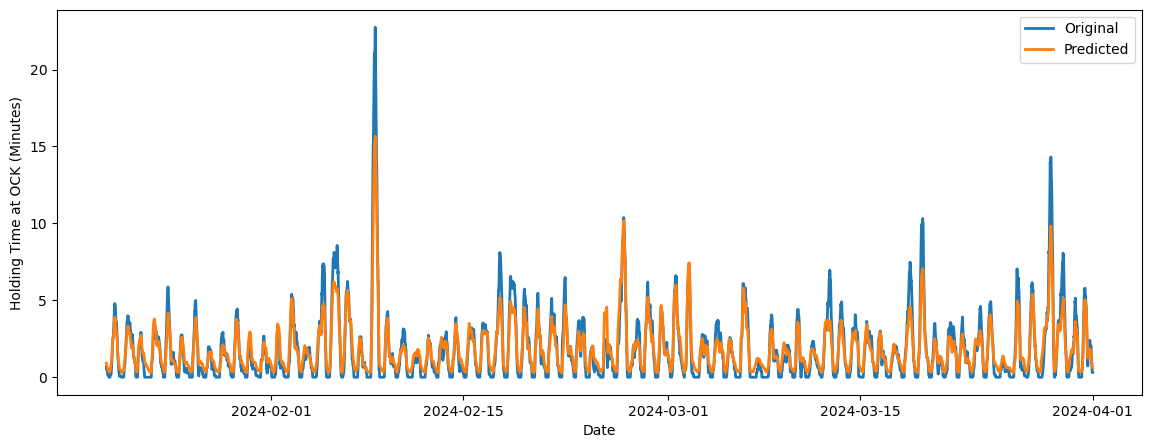

In [18]:
# Flatten arrays to 1D
original_rescaled_flat = original_rescaled.ravel()
predictions_rescaled_flat = predictions_rescaled.ravel()

# Convert to pandas Series with date index
original_series = pd.Series(original_rescaled_flat, index=adjusted_test_index)
predicted_series = pd.Series(predictions_rescaled_flat, index=adjusted_test_index)

# Apply rolling average 
window = 24  #(4=1hour 24=6hours)
original_smoothed = original_series.rolling(window).mean()
predicted_smoothed = predicted_series.rolling(window).mean()

# Plot smoothed data
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_smoothed, label='Original', linewidth=2)
plt.plot(adjusted_test_index, predicted_smoothed, label='Predicted', linewidth=2)

plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
#plt.grid(True)
#plt.tight_layout()
plt.show()


In [22]:
# ================================
# Step 2: Define features and target.
features = list(df.columns)  
target = "Holding Time at BNN"  # Forecast this column

# ================================
# Step 3: Prepare the data.
X = df[features].values
y = df[target].values.reshape(-1, 1)

# ================================
# Step 4: Scale the data (inputs and target separately)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# ================================
# Step 5: Create time-window sequences.
def createXY(X, y, n_past):
    dataX, dataY = [], []
    for i in range(n_past, len(X)):
        dataX.append(X[i - n_past:i, :])
        dataY.append(y[i, 0])
    return np.array(dataX), np.array(dataY)

n_past = 30  # length of the time window

split_index = int(len(df) * 0.80)
X_train_scaled, X_test_scaled = X_scaled[:split_index], X_scaled[split_index:]
y_train_scaled, y_test_scaled = y_scaled[:split_index], y_scaled[split_index:]

trainX, trainY = createXY(X_train_scaled, y_train_scaled, n_past)
testX, testY   = createXY(X_test_scaled, y_test_scaled, n_past)
print("trainX shape:", trainX.shape, "trainY shape:", trainY.shape)
print("testX shape:", testX.shape, "testY shape:", testY.shape)

# ================================
# Step 6: Define the LSTM model creation function.
# Now we include learning_rate and dropout as arguments.
def build_model(input_shape, optimizer='adam', learning_rate=0.001, dropout=0.2):
    # Create an optimizer instance with the chosen learning rate
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'adadelta':
        opt = tf.keras.optimizers.Adadelta(learning_rate=learning_rate)
    else:
        # Fallback
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(50, return_sequences=True))
    model.add(LSTM(50))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=opt)
    return model

# ================================
# (Optional) Step 7: Define a forecasting function.
def forecast(model, X_dataset, n_past, n_future):
    # Use the last window from X_dataset as the starting point.
    forecast_input = X_dataset[-n_past:]  # shape: (n_past, num_features)
    forecast_output = []
    for _ in range(n_future):
        forecast_input_reshaped = forecast_input.reshape(1, n_past, forecast_input.shape[1])
        prediction = model.predict(forecast_input_reshaped)
        forecast_output.append(prediction[0, 0])
        # For forecasting, update only the target feature (assumed to be the first column).
        new_input = forecast_input[-1].copy()
        new_input[0] = prediction
        forecast_input = np.vstack([forecast_input[1:], new_input])
    return np.array(forecast_output)

# ================================
# Step 8: Hyperparameter tuning using GridSearchCV with scikeras.
input_shape = (trainX.shape[1], trainX.shape[2])

grid_model = KerasRegressor(
    model=build_model,
    input_shape=input_shape,
    # Default top-level parameters
    optimizer="adam",
    epochs=10,
    batch_size=32,
    verbose=1,
    # Default custom model parameters
    model__dropout=0.2,
    model__learning_rate=0.01
)

parameters = {
    'batch_size': [16, 32],              # top-level param
    'epochs': [8, 10],                   # top-level param
    'optimizer': ['adam', 'adadelta'],   # top-level param
    'model__learning_rate': [0.01, 0.05, 0.1],  # custom model param
    'model__dropout': [0.2, 0.4,0.6],           # custom model param
}

grid_search = GridSearchCV(estimator=grid_model, param_grid=parameters, cv=2)
print("Starting GridSearchCV...")
grid_search.fit(trainX, trainY)


trainX shape: (27848, 30, 49) trainY shape: (27848,)
testX shape: (6940, 30, 49) testY shape: (6940,)
Starting GridSearchCV...
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - loss: 0.0108
Epoch 2/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0043
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - loss: 0.0041
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - loss: 0.0043
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - loss: 0.0040
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - loss: 0.0040
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - loss: 0.0040
Epoch 8/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - loss: 0.0040
871/871 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - loss: 0.0056
Epoch 2/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - loss: 0.0027
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - loss: 0.0027
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - loss: 0.0025
Epoch 5/8
871/8

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0117
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0096
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - loss: 0.0119
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 0.0120
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0118
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0120
Epoch 8/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0122
871/871 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
Epoch 1/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - loss: 0.1220
Epoch 2/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - loss: 0.0108
Epoch 3/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0068
Epoch 4/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 0.0052
Epoch 5/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0081
Epoch 6/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0086
Epoch 7/8
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0080
Epoch 8/8
871/871

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0039
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 0.0039
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0040
Epoch 9/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0038
Epoch 10/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0038
871/871 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
Epoch 1/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - loss: 0.0070
Epoch 2/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0027
Epoch 3/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0026
Epoch 4/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 0.0025
Epoch 5/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0027
Epoch 6/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 0.0025
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0025
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0024
Epoch 9/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0022
Epo

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0039
Epoch 6/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 0.0036
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0040
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - loss: 0.0040
Epoch 9/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0038
Epoch 10/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - loss: 0.0044
871/871 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
Epoch 1/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - loss: 0.0576
Epoch 2/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0057
Epoch 3/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 0.0057
Epoch 4/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 0.0063
Epoch 5/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0082
Epoch 6/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - loss: 0.0087
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - loss: 0.0115
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - loss: 0.0122
Epo

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0046
Epoch 4/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0045
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 0.0042
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 0.0043
Epoch 9/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0043
Epoch 10/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0041
871/871 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step
Epoch 1/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.0080
Epoch 2/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0032
Epoch 3/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0027
Epoch 4/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0029
Epoch 5/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - loss: 0.0027
Epoch 6/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - loss: 0.0027
Epoch 7/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0028
Epoch 8/10
871/871 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - loss: 0.0027
Epo

GridSearchCV(cv=2,
             estimator=KerasRegressor(batch_size=32, epochs=10, input_shape=(30, 49), model=<function build_model at 0x000001B9BCA0C700>, model__dropout=0.2, model__learning_rate=0.01, optimizer='adam'),
             param_grid={'batch_size': [16, 32], 'epochs': [8, 10],
                         'model__dropout': [0.2, 0.4, 0.6],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'optimizer': ['adam', 'adadelta']})

In [ ]:
print("Grid Search Parameter grid:", grid_search.param_grid)
print("Best parameters:", grid_search.best_params_)

# Extract best Keras model
best_model = grid_search.best_estimator_.model_

# ================================
# Step 9: Evaluate the model on the test set.
predictions = best_model.predict(testX)
predictions_rescaled = scaler_y.inverse_transform(predictions)
original_rescaled = scaler_y.inverse_transform(testY.reshape(-1, 1))
mae = mean_absolute_error(original_rescaled, predictions_rescaled)
mse = mean_squared_error(original_rescaled, predictions_rescaled)
mape = mean_absolute_percentage_error(original_rescaled, predictions_rescaled)
print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test MAPE:", mape, "%")

Grid Search Parameter grid: {'batch_size': [16, 32], 'epochs': [8, 10], 'optimizer': ['adam', 'adadelta'], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__dropout': [0.2, 0.4, 0.6]}
Best parameters: {'batch_size': 32, 'epochs': 8, 'model__dropout': 0.6, 'model__learning_rate': 0.01, 'optimizer': 'adadelta'}
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
Test MAE: 1.625290257561018
Test MSE: 7.113443642780166
Test MAPE: 5988943515.802201 %


shap_AddV2 gradient already registered. Skipping re-registration.
X_train_flat shape: (27848, 1470)
X_test_flat shape: (6940, 1470)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Calculating SHAP values on test subset...


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
7519/7519 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
7525/7525 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/stepms/step 
7513/7513 ━━━━━━━━━━━━━━━━━━━━ 79s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
7516/7516 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 79s 10ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 79s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
 635/7513 ━━━━━━━━━━━━━━━━━━━━ 1:18 11ms/step

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



7513/7513 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 79s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 79s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 79s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75

C:\Users\mic__\AppData\Local\Temp\ipykernel_14212\517822863.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_input[0] = prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/s

C:\Users\mic__\AppData\Local\Temp\ipykernel_14212\20548665.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_dates = pd.date_range(last_date, periods=n_future+1, freq='15T')[1:]


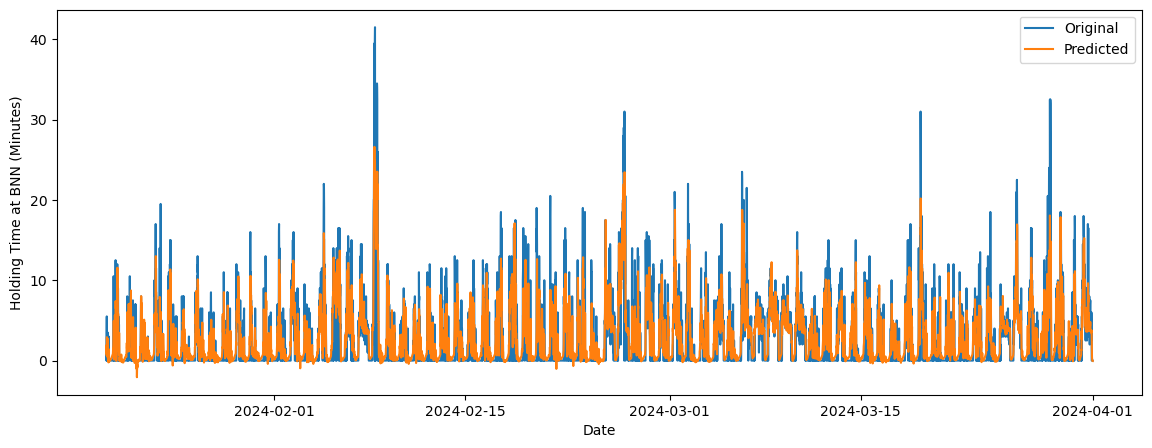

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [ ]:
# ================================
# Step 10: SHAP Analysis and Beeswarm Plot for All Features.
import shap

try:
    @tf.RegisterGradient("shap_AddV2")
    def _shap_add_v2_grad(op, grad):
        return [grad, tf.zeros_like(grad)]
except KeyError:
    print("shap_AddV2 gradient already registered. Skipping re-registration.")

X_train_flat = trainX.reshape(trainX.shape[0], -1)
X_test_flat  = testX.reshape(testX.shape[0], -1)
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

def predict_function(flat_data):
    batch_size = flat_data.shape[0]
    reshaped = flat_data.reshape((batch_size, n_past, trainX.shape[2]))
    return best_model.predict(reshaped).flatten()

np.random.seed(42)
idx = np.random.choice(X_train_flat.shape[0], size=50, replace=False)
background_data = X_train_flat[idx]

explainer = shap.KernelExplainer(model=predict_function, data=background_data, link="identity")

test_subset = X_test_flat[:100]
print("Calculating SHAP values on test subset...")
shap_values = explainer.shap_values(test_subset)
print("SHAP values shape (flattened):", np.array(shap_values).shape)

num_samples = test_subset.shape[0]
n_features = trainX.shape[2]
shap_values_reshaped = np.array(shap_values).reshape(num_samples, n_past, n_features)

aggregated_shap = np.mean(shap_values_reshaped, axis=1)  # (num_samples, n_features)

test_subset_unflat = testX[:100]
aggregated_X_test = np.mean(test_subset_unflat, axis=1)  # (num_samples, n_features)

shap.summary_plot(aggregated_shap, aggregated_X_test, feature_names=features, max_display=10, show=False)
plt.tight_layout()
plt.savefig(f'plots\LSTM\{target}\Aggregated_Beeswarm_All_Features.png')
plt.close()
print("Aggregated beeswarm plot saved as 'Aggregated_Beeswarm_All_Features.png'.")

# ================================
# Step 11: (Optional) Forecast future target values.
n_future = 50
forecasted_scaled = forecast(best_model, X_train_scaled, n_past, n_future)
forecasted = scaler_y.inverse_transform(forecasted_scaled.reshape(-1, 1)).flatten()

# ================================
# Step 12: Generate future dates for forecasting.
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=n_future+1, freq='15T')[1:]

# ================================
# Step 13: Plot the test predictions and forecast.
adjusted_test_index = df.index[split_index + n_past:]
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_rescaled, label='Original')
plt.plot(adjusted_test_index, predictions_rescaled, label='Predicted')
#plt.plot(future_dates, forecasted, label='Forecasted', linestyle='dashed', color='green')
#plt.title("Prediction and Forecasting")
plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
plt.show()

# ================================
# Step 14: Save the results to CSV.
results_df = pd.DataFrame({
    'Date': adjusted_test_index.tolist() + future_dates.tolist(),
    'Original': np.concatenate([original_rescaled, [np.nan]*len(future_dates)]),
    'Predicted': np.concatenate([predictions_rescaled, [np.nan]*len(future_dates)]),
    'Forecasted': np.concatenate([[np.nan]*len(original_rescaled), forecasted])
})
results_df.to_csv("Multivariate_Results_BNN.csv", index=False)
print("Results saved to 'Multivariate_Result_BNNs.csv'.")

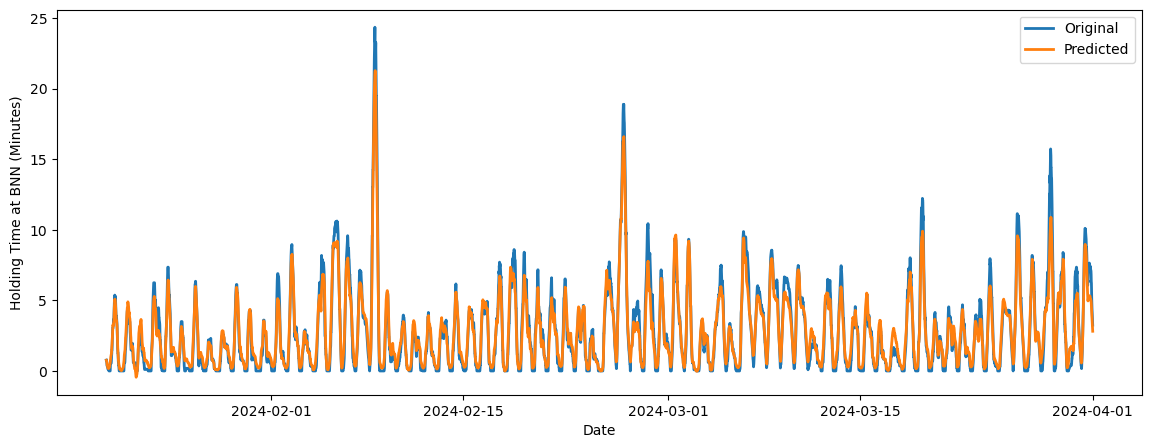

In [25]:
# Flatten arrays to 1D
original_rescaled_flat = original_rescaled.ravel()
predictions_rescaled_flat = predictions_rescaled.ravel()

# Convert to pandas Series with date index
original_series = pd.Series(original_rescaled_flat, index=adjusted_test_index)
predicted_series = pd.Series(predictions_rescaled_flat, index=adjusted_test_index)

# Apply rolling average 
window = 24  #(4=1hour 24=6hours)
original_smoothed = original_series.rolling(window).mean()
predicted_smoothed = predicted_series.rolling(window).mean()

# Plot smoothed data
plt.figure(figsize=(14, 5))
plt.plot(adjusted_test_index, original_smoothed, label='Original', linewidth=2)
plt.plot(adjusted_test_index, predicted_smoothed, label='Predicted', linewidth=2)

plt.xlabel("Date")
plt.ylabel(f"{target} (Minutes)")
plt.legend()
#plt.grid(True)
#plt.tight_layout()
plt.show()


In [ ]:
df.columns